# Семинар 1: Text Retrieval — от TF-IDF до нейронного поиска



## Цели семинара

После выполнения этого семинара вы научитесь:

1. Понимать разницу между **полнотекстовым** (BM25) и **векторным** поиском
2. Использовать **sentence-transformers** для получения плотных эмбеддингов текста
3. Строить **ANN-индексы** в FAISS (Flat, IVF, HNSW) для быстрого поиска
4. Считать стандартные **метрики качества** retrieval (Recall@k, MRR, NDCG)
5. Строить **reranking pipeline**: Bi-Encoder + Cross-Encoder

**Связь с конспектами:** 1.2 (генерация vs извлечение — retrieval как задача извлечения информации), 1.3 (Text Retrieval), 1.4 (Методы поиска информации)


`Время выполнения в среде T4 на 16.02.26 - 3 минуты`

## Блок 0: Настройка окружения

In [ ]:
# Установка зависимостей (для Google Colab)
# При локальном запуске можно пропустить, если пакеты уже установлены
!pip install -q transformers datasets evaluate accelerate sentencepiece
!pip install -q sentence-transformers rank-bm25
# faiss-gpu для GPU-окружений, faiss-cpu как запасной вариант. Такая реализация на bash позволит быть универсальным относительно окружений (особенно для windows, где faiss-gpu не установить)
!pip install -q faiss-gpu 2>/dev/null || pip install -q faiss-cpu
# 2>/dev/null - это перенаправление потока ошибок "в никуда"
# Оператор || (ИЛИ) в Bash означает: выполни выражение справа ТОЛЬКО если команда слева завершилась с ошибкой

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 90.9 MB/s eta 0:00:00


In [ ]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    device = torch.device("cpu")
    print("WARNING: GPU не доступен, используется CPU")
    print("Семинар будет работать на CPU, но медленнее")

GPU: Tesla T4
VRAM: 14.6 GB


In [ ]:
import numpy as np
import time
from tqdm.auto import tqdm

## Блок 0.5: Загрузка данных

Будем работать с датасетом **Gazeta** — коллекцией русскоязычных новостей. Каждая статья содержит заголовок и текст. Мы будем использовать **заголовки как запросы**, а **тексты как документы** — это создаёт естественные пары для оценки качества поиска.
На самом деле в работе при оценке RAG систем самой сложной задачей будет сбор релевантных документов запросам.

Возьмём подмножество из 10 000 статей, чтобы семинар работал быстро.

In [ ]:
from datasets import load_dataset

# Загружаем датасет gazeta из HuggingFace Hub
raw_dataset = load_dataset("IlyaGusev/gazeta", "default", split="train")
print(f"Всего статей: {len(raw_dataset)}")
print(f"Колонки: {raw_dataset.column_names}")
print(f"\nПример:")
print(f"  Заголовок: {raw_dataset[0]['title']}")
print(f"  Текст (первые 200 символов): {raw_dataset[0]['text'][:200]}...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

default/train/0000.parquet:   0%|          | 0.00/252M [00:00<?, ?B/s]

default/train/0001.parquet:   0%|          | 0.00/22.7M [00:00<?, ?B/s]

default/validation/0000.parquet:   0%|          | 0.00/27.8M [00:00<?, ?B/s]

default/test/0000.parquet:   0%|          | 0.00/30.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60964 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6369 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6793 [00:00<?, ? examples/s]

Всего статей: 60964
Колонки: ['text', 'summary', 'title', 'date', 'url']

Пример:
  Заголовок: Налог в бак
  Текст (первые 200 символов): Сегодня транспортный налог начисляется в зависимости от мощности автомобиля, причем цена для «сильных» машин выше, чем для малолитражек. Также ставку налога могут корректировать региональные власти: с...


In [ ]:
# Берём подмножество для скорости работы на семинаре
N_DOCS = 10_000
dataset = raw_dataset.shuffle(seed=42).select(range(N_DOCS))

# Для поиска используем первые 500 символов текста (вместо полного)
# Это ускоряет BM25 и делает эмбеддинги более осмысленными
documents = [text[:500] for text in dataset["text"]]
titles = dataset["title"]

print(f"Корпус: {len(documents)} документов")
print(f"Средняя длина документа: {np.mean([len(d) for d in documents]):.0f} символов")

Корпус: 10000 документов
Средняя длина документа: 500 символов


In [ ]:
# Создадим набор запросов для оценки: используем заголовки статей
# Правильный ответ — документ с тем же индексом
N_QUERIES = 200
query_indices = list(range(N_QUERIES))
queries = [titles[i] for i in query_indices]
# ground_truth[i] = индекс правильного документа для i-го запроса
ground_truth = query_indices

print(f"Запросов для оценки: {len(queries)}")
print(f"Пример запроса: '{queries[0]}'")
print(f"Правильный документ: '{documents[ground_truth[0]][:100]}...'")

Запросов для оценки: 200
Пример запроса: '«Мы проведем тщательное расследование»'
Правильный документ: 'В сети появилось видео задержания 58-летнего водителя Виктора Тихонова , который за рулем рейсового ...'


Да, это не совсем соответствует релевантности, потому что часто используются "желтые" заголовки. Но для упрощения задачи мы на семинаре этим пренебрегаем.

---

## Блок 1: Sparse Retrieval — BM25

### Теория: от TF-IDF к BM25

В конспекте 1.4 был разобран **TF-IDF** — классический метод векторизации текста. Его главное ограничение: частота термина растёт линейно, а на практике 10 повторений слова не делают документ в 10 раз релевантнее.

**BM25 (Best Matching 25)** — улучшение TF-IDF, которое решает эту проблему двумя способами:

1. **Насыщение частоты (saturation)**: вклад частоты термина ограничен сверху
2. **Нормализация по длине документа**: длинные документы не получают несправедливого преимущества, когда чисто статистически имееют большее кол-во повторений релевантных слов.

$$\text{BM25}(q, d) = \sum_{t \in q} \text{IDF}(t) \cdot \frac{f(t, d) \cdot (k_1 + 1)}{f(t, d) + k_1 \cdot \left(1 - b + b \cdot \frac{|d|}{\text{avgdl}}\right)}$$

Где:
- $f(t, d)$ — частота термина $t$ в документе $d$
- $|d|$ — длина документа, $\text{avgdl}$ — средняя длина документа в корпусе
- $k_1$ — управляет насыщением (обычно 1.2–2.0)
- $b$ — управляет нормализацией по длине (обычно 0.75)

При $k_1 \to \infty$ и $b = 0$ формула сводится к обычному TF-IDF.

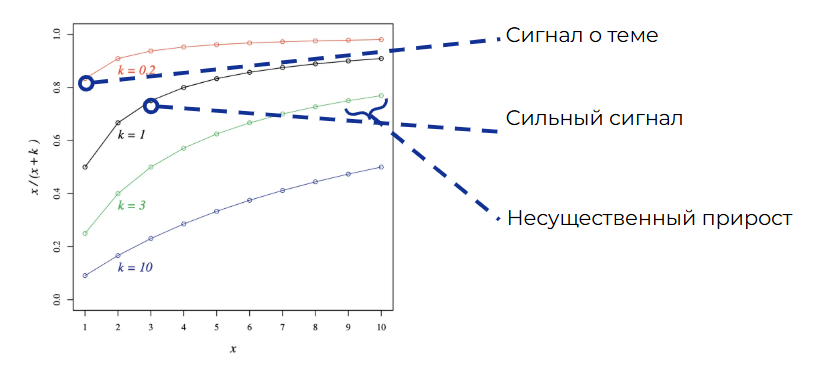

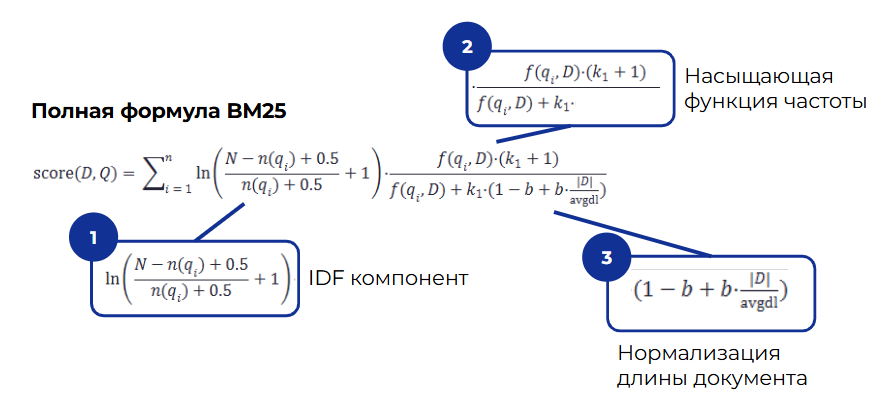

In [ ]:
from rank_bm25 import BM25Okapi

# Токенизация для BM25: простое разбиение по пробелам + приведение к нижнему регистру
# В продакшене стоит использовать морфологический анализатор (pymorphy3) для лемматизации, стемминга,
# но для демонстрации хватит простого подхода
tokenized_docs = [doc.lower().split() for doc in documents]

print("Строим BM25-индекс...")
bm25 = BM25Okapi(tokenized_docs)
print(f"Словарь: {len(bm25.idf)} уникальных токенов")
print(f"Средняя длина документа: {bm25.avgdl:.1f} токенов")

Строим BM25-индекс...
Словарь: 125345 уникальных токенов
Средняя длина документа: 69.0 токенов


In [ ]:
def bm25_search(query: str, bm25: BM25Okapi, top_k: int = 10) -> list[int]:
    """Поиск top_k документов по BM25."""
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_indices = np.argsort(scores)[::-1][:top_k]
    return top_indices.tolist()


# Демо: поиск по одному запросу
demo_query = queries[0]
results = bm25_search(demo_query, bm25, top_k=5)

print(f"Запрос: '{demo_query}'\n")
print("Результаты BM25:")
for rank, idx in enumerate(results, 1):
    marker = " ✓" if idx == ground_truth[0] else ""
    print(f"  {rank}. [{idx}] {titles[idx][:80]}{marker}")

Запрос: '«Мы проведем тщательное расследование»'

Результаты BM25:
  1. [0] «Мы проведем тщательное расследование» ✓
  2. [2758] Банк в кепке
  3. [889] «С Лесуном и Карякиным пересекаемся на турнирах»
  4. [6787] Американцы занялись Google
  5. [8610] Государство долю не бережет


In [ ]:
# Оценим BM25 на всех запросах
print("Оцениваем BM25 на всех запросах...")
start = time.time()
bm25_results = [bm25_search(q, bm25, top_k=20) for q in tqdm(queries)]
bm25_time = time.time() - start

# Простая метрика: в скольких случаях правильный документ в top-k?
for k in [1, 5, 10, 20]:
    hits = sum(1 for i, res in enumerate(bm25_results) if ground_truth[i] in res[:k])
    print(f"  Recall@{k}: {hits / len(queries):.3f}")
print(f"  Время: {bm25_time:.2f} сек ({len(queries)} запросов)")

Оцениваем BM25 на всех запросах...


  0%|          | 0/200 [00:00<?, ?it/s]

  Recall@1: 0.190
  Recall@5: 0.290
  Recall@10: 0.340
  Recall@20: 0.375
  Время: 2.85 сек (200 запросов)


BM25 - хорошее базовое решение, его используют например в ElasticSearch по умолчанию. Он работает быстро и не требует GPU, но имеет ограничение: поиск основан на **лексическом совпадении** — если в запросе и документе используются разные слова для одного понятия (синонимы), BM25 их не найдёт.




## Блок 2: Векторный поиск - Sentence Transformers

### Теория:

В конспекте 1.3 мы рассматривались два типа нейронных моделей для задачи информационного поиска (retrieval - в аббревиатуре RAG первая буква):

**Bi-Encoder** кодирует запрос и документ **независимо** в плотные векторы  фиксированной размерности (эмбеддинги), а затем сравнивает их через косинусное или другое расстояние. Это позволяет предвычислить эмбеддинги документов и искать быстро в реальном времени вычисляя только эмбеддинг запроса.

**Cross-Encoder** получает на вход пару (запрос, документ) **вместе** через  токен разделения пары и выдаёт скор релевантности. Точнее, но не масштабируется — нельзя предвычислить.

### Современные embedding-модели

С 2023–2024 года появилось семейство моделей, специально обученных для retrieval, примерно так выглядел топ на MTEB:

| Модель | Размер | Retrieval скор | Особенность |
|--------|--------|-------------|--------|
| **E5** (intfloat) | 418M | 35.22 | Обучена на парах запрос-документ (query-passage) парах, префикс `"query:"` / `"passage:"` |
| **BGE** (BAAI) | 390M | 18.40 | Аналог E5, хорошо работает на многих бенчмарках, эта версия не требует префиксов |
| **GTE** (Alibaba) | 209M | 33.09 | Новейшее семейство на тот момент `instruction-aware`, которое потом перекочует на арх Qwen |

Ключевая особенность E5/BGE: при кодировании нужно добавлять **префикс** к тексту:
- Для запроса: `"query: {текст запроса}"`
- Для документа: `"passage: {текст документа}"`

Мы будем использовать **multilingual-e5-small** — компактную multilingual модель, поддерживающую русский язык.

Посмотрим на актуальный на февраль 26 года лидерборд MTEB:
| Модель | Размер | Retrieval скор | Особенность |
|--------|--------|-------------|--------|
| **KaLM-Embedding-Gemma3-12B-2511** (tencent) | 44.9G | 75.66 | Обучена на парах запрос-документ (query-passage) парах, префикс `"query:"` / `"passage:"` |
| **llama-embed-nemotron-8b** (NVIDIA) | 28.6G | 68.69 | Аналог E5, хорошо работает на многих бенчмарках |
| **Qwen3-Embedding-8B** (Alibaba) | 14.4G | 70.88 | Новейшее семейство на тот момент, которое потом перекочует на арх Qwen |

In [ ]:
from sentence_transformers import SentenceTransformer

# multilingual-e5-small: 471 MB, 384-мерные эмбеддинги, поддержка 100+ языков
bi_encoder = SentenceTransformer("intfloat/multilingual-e5-small", device=str(device))
print(f"Модель: {bi_encoder.get_sentence_embedding_dimension()}-мерные эмбеддинги")
print(f"Макс. длина: {bi_encoder.max_seq_length} токенов")

In [ ]:
# E5 требует префиксы для разделения запросов и документов
# Это помогает модели понять "роль" текста
docs_with_prefix = [f"passage: {doc}" for doc in documents]

print("Кодируем корпус документов (это может занять 1-3 минуты)...")
start = time.time()
doc_embeddings = bi_encoder.encode(
    docs_with_prefix,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True  # L2-нормализация: косинусное сходство = скалярному произведению
)
encode_time = time.time() - start

print(f"\nФорма матрицы эмбеддингов: {doc_embeddings.shape}")
print(f"Время кодирования: {encode_time:.1f} сек ({len(documents)/encode_time:.0f} док/сек)")
print(f"Размер в памяти: {doc_embeddings.nbytes / 1024**2:.1f} MB")

Кодируем корпус документов (это может занять 1-3 минуты)...


Batches:   0%|          | 0/157 [00:00<?, ?it/s]


Форма матрицы эмбеддингов: (10000, 384)
Время кодирования: 30.0 сек (334 док/сек)
Размер в памяти: 14.6 MB


In [ ]:
def dense_search(query: str, model: SentenceTransformer, doc_embs: np.ndarray, top_k: int = 10) -> list[int]:
    """Поиск top_k документов через векторный поиск (brute-force)."""
    query_emb = model.encode(
        f"query: {query}",
        normalize_embeddings=True
    )
    # косинусное сходство = скалярному произведению (т.к. векторы нормализованы)
    scores = doc_embs @ query_emb
    top_indices = np.argsort(scores)[::-1][:top_k]
    return top_indices.tolist()


# Демо: тот же запрос, что и для BM25
results = dense_search(demo_query, bi_encoder, doc_embeddings, top_k=5)

print(f"Запрос: '{demo_query}'\n")
print("Результаты Векторного поиска:")
for rank, idx in enumerate(results, 1):
    marker = " ✓" if idx == ground_truth[0] else ""
    print(f"  {rank}. [{idx}] {titles[idx][:80]}{marker}")

Запрос: '«Мы проведем тщательное расследование»'

Результаты Dense Retrieval:
  1. [4379] Никаких оправданий: следователи проверят приговоры
  2. [7146] «Российское дело»: в США спросят с агентов ЦРУ
  3. [1436] Ту-154 раскачался до проверки
  4. [6406] Кокаин перемешали с бананами
  5. [8510] О Кашине узнали в США


In [ ]:
# Оценим dense retrieval на всех запросах
# Для простоты кодируем по одному запросу. В Блоке 3 используем batch-кодирование через FAISS
print("Оцениваем Dense Retrieval (brute-force)...")
start = time.time()
dense_results = [dense_search(q, bi_encoder, doc_embeddings, top_k=20) for q in tqdm(queries)]
dense_bf_time = time.time() - start

for k in [1, 5, 10, 20]:
    hits = sum(1 for i, res in enumerate(dense_results) if ground_truth[i] in res[:k])
    print(f"  Recall@{k}: {hits / len(queries):.3f}")
print(f"  Время: {dense_bf_time:.2f} сек ({len(queries)} запросов)")

Оцениваем Dense Retrieval (brute-force)...


  0%|          | 0/200 [00:00<?, ?it/s]

  Recall@1: 0.360
  Recall@5: 0.505
  Recall@10: 0.535
  Recall@20: 0.615
  Время: 3.25 сек (200 запросов)


### Сравнение BM25 vs векторный поиск

Векторный поиск (Dense retrieval) ловит **семантическое сходство** — синонимы, перефразировки. Но на точных совпадениях BM25 может быть лучше. В реальных системах часто используют **гибридный подход**.

Обратите внимание на скорость: векторный поиск брут форсом медленнее BM25, потому что считает скалярное произведение с каждым из 10 000 документов. При масштабе в миллионы документов это становится неприемлемо. Решение — **ANN-индексы**.

---

## Блок 3: ANN-поиск с FAISS

### Теория: Approximate Nearest Neighbors

В конспекте 1.4 мы подробно разобрали алгоритмы приближённого поиска (ANN). Основная идея: **пожертвовать немного точностью ради многократного ускорения поиска**.

**FAISS** (Facebook AI Similarity Search) — самая популярная библиотека для ANN-поиска. Мы рассмотрим три типа индексов:

| Индекс | Принцип | Время поиска | Recall | Память |
|--------|---------|-------------|--------|--------|
| **IndexFlatIP** | Точный перебор | O(n·d) | 100% | n·d·4 байт |
| **IndexIVFFlat** | Кластеризация (IVF из конспекта 1.4) | O(n/k·d) | ~95-99% | n·d·4 байт |
| **IndexHNSWFlat** | Граф (HNSW из конспекта 1.4) | O(log n·d) | ~98-99% | n·d·4 + граф |

Где $n$ — число документов, $d$ — размерность эмбеддинга, $k$ — число кластеров.

**Product Quantization (PQ)** — дополнительная техника, которая **сжимает** эмбеддинги, разбивая каждый вектор на подвекторы и квантуя их. Это уменьшает потребление памяти в 4–16 раз ценой небольшой потери точности.

In [ ]:
import faiss

d = doc_embeddings.shape[1]  # размерность эмбеддингов
print(f"Размерность эмбеддингов: {d}")
print(f"Число документов: {len(doc_embeddings)}")

# Приведём к float32 (FAISS требует этого)
doc_embeddings_f32 = doc_embeddings.astype(np.float32)

Размерность эмбеддингов: 384
Число документов: 10000


### IndexFlatIP — точный поиск (база)

Полный перебор через Inner Product. Результаты точно такие же, как brute-force, но FAISS реализует это оптимальнее (SIMD, многопоточность).

In [ ]:
# IndexFlatIP: точный поиск по inner product (IP метрика = cosine sim для наших нормализованных векторов)
index_flat = faiss.IndexFlatIP(d)
index_flat.add(doc_embeddings_f32)

print(f"Индекс Flat: {index_flat.ntotal} векторов")

Индекс Flat: 10000 векторов


### IndexIVFFlat — кластерный поиск

Из конспекта 1.4: IVF делит пространство на **кластеры** (через K-means), а при поиске проверяет только `nprobe` ближайших кластеров вместо всех документов.

In [ ]:
# IVF: сначала обучаем кластеры, потом добавляем данные
nlist = 100  # число кластеров (эвристика: sqrt(n) до 4*sqrt(n))
quantizer = faiss.IndexFlatIP(d)  # кластеризатор использует точный поиск
index_ivf = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_INNER_PRODUCT)

# Обучение (K-means на данных)
print("Обучаем IVF-индекс (K-means)...")
index_ivf.train(doc_embeddings_f32)
index_ivf.add(doc_embeddings_f32)

# nprobe: сколько кластеров проверять при поиске (больше = точнее, но медленнее)
index_ivf.nprobe = 10

print(f"Индекс IVF: {index_ivf.ntotal} векторов, {nlist} кластеров, nprobe={index_ivf.nprobe}")

Обучаем IVF-индекс (K-means)...
Индекс IVF: 10000 векторов, 100 кластеров, nprobe=10


### IndexHNSWFlat — графовый поиск

Из конспекта 1.4: HNSW строит **иерархический граф** «малого мира». Поиск начинается с верхнего уровня и спускается вниз, на каждом уровне двигаясь к ближайшим соседям.

In [ ]:
# HNSW: M — число связей на узел (больше = точнее, но больше памяти)
# Метрику ОБЯЗАТЕЛЬНО передаём в конструктор — установка metric_type после создания НЕ работает
M = 32
index_hnsw = faiss.IndexHNSWFlat(d, M, faiss.METRIC_INNER_PRODUCT)

# efConstruction: точность при построении графа (больше = лучший граф, но дольше)
index_hnsw.hnsw.efConstruction = 200

print("Строим HNSW-индекс...")
index_hnsw.add(doc_embeddings_f32)

# efSearch: точность при поиске (больше = точнее, но медленнее)
index_hnsw.hnsw.efSearch = 50

print(f"Индекс HNSW: {index_hnsw.ntotal} векторов, M={M}")

Строим HNSW-индекс...
Индекс HNSW: 10000 векторов, M=32


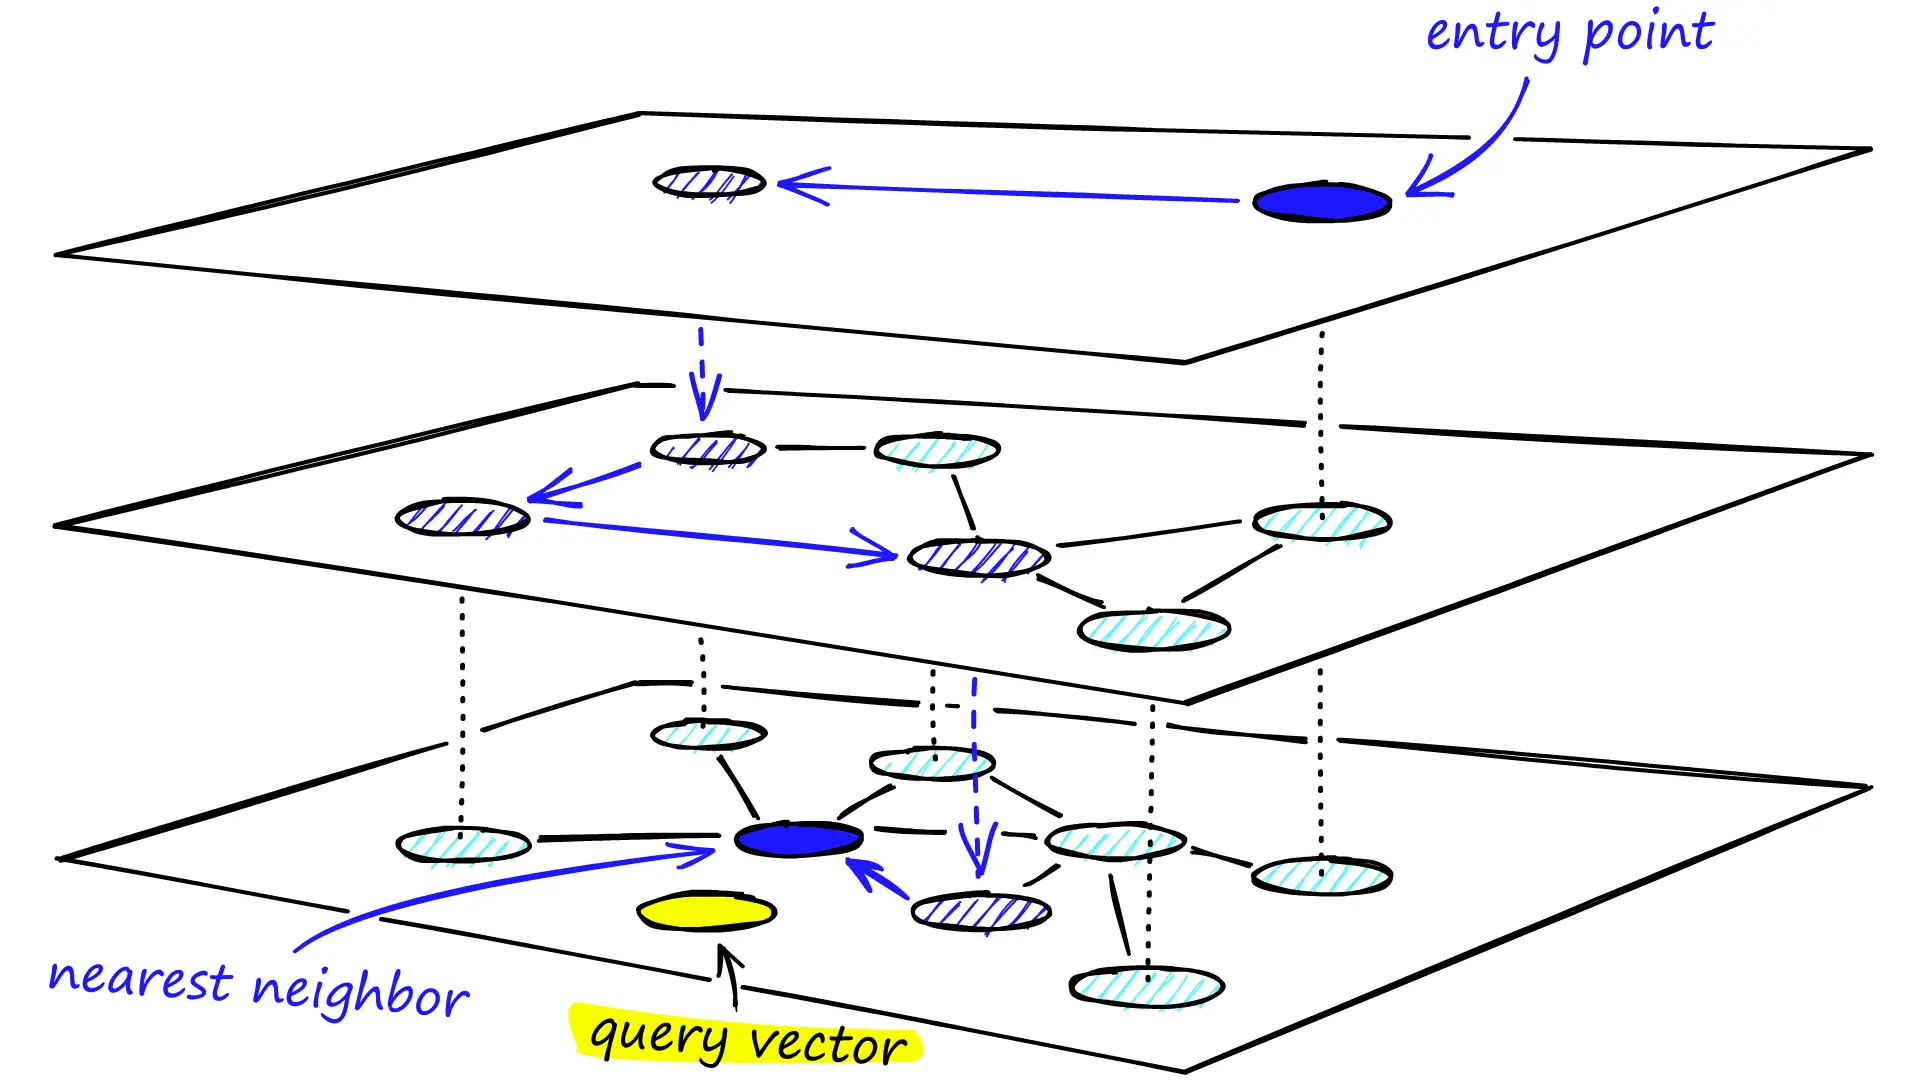

### Сравнение индексов: скорость vs качество

In [ ]:
def faiss_search_batch(index, queries_list: list[str], model: SentenceTransformer, top_k: int = 20):
    """Batch-поиск через FAISS-индекс."""
    query_embs = model.encode(
        [f"query: {q}" for q in queries_list],
        normalize_embeddings=True,
        batch_size=128
    ).astype(np.float32)

    scores, indices = index.search(query_embs, top_k)
    return indices.tolist()


# Прогреваем кэш (первый вызов .encode может быть медленнее)
_ = bi_encoder.encode(["warmup"], normalize_embeddings=True)

# Замеряем только время поиска (без кодирования запросов)
query_embs = bi_encoder.encode(
    [f"query: {q}" for q in queries],
    normalize_embeddings=True,
    batch_size=128
).astype(np.float32)

results_all = {}
times_all = {}

for name, index in [("Flat (точный)", index_flat), ("IVF", index_ivf), ("HNSW", index_hnsw)]:
    start = time.time()
    _, indices = index.search(query_embs, 20)
    elapsed = time.time() - start
    results_all[name] = indices.tolist()
    times_all[name] = elapsed

# Выводим результаты
# print(f"{'Индекс':<20} {'Время (мс)':<15} {'Recall@1':<12} {'Recall@5':<12} {'Recall@10':<12} {'Recall@20':<12}")
# print("-" * 83)

# for name, res in results_all.items():
#     recalls = []
#     for k in [1, 5, 10, 20]:
#         hits = sum(1 for i, r in enumerate(res) if ground_truth[i] in r[:k])
#         recalls.append(f"{hits / len(queries):.3f}")
#     print(f"{name:<20} {times_all[name]*1000:<15.1f} {'  '.join(recalls)}")

from tabulate import tabulate

headers = ["Индекс", "Время (мс)", "Recall@1", "Recall@5", "Recall@10", "Recall@20"]
rows = []

for name, res in results_all.items():
    recalls = []
    for k in [1, 5, 10, 20]:
        hits = sum(1 for i, r in enumerate(res) if ground_truth[i] in r[:k])
        recalls.append(f"{hits / len(queries):.3f}")
    rows.append([name, f"{times_all[name]*1000:.1f}", *recalls])

print(tabulate(rows, headers=headers, tablefmt="rounded_outline", colalign=("left", "right", "center", "center", "center", "center")))

Индекс               Время (мс)      Recall@1     Recall@5     Recall@10    Recall@20   
-----------------------------------------------------------------------------------
Flat (точный)        22.4            0.360  0.505  0.535  0.615
IVF                  17.9            0.310  0.435  0.460  0.525
HNSW                 33.0            0.355  0.500  0.535  0.615


На 10 000 документов разница в скорости небольшая — все индексы работают быстро. Преимущества IVF и HNSW проявляются на масштабе **от сотен тысяч документов**. Но даже здесь видно, что IVF и HNSW дают **почти такой же Recall**, как точный поиск.

---

## Блок 4: Метрики качества Retrieval

### Теория

В конспекте 1.3 вы разобрали метрики для задач Text Retrieval. Реализуем основные:

**Precision@k** — доля релевантных документов среди top-k:

$$\text{Precision@k} = \frac{|\text{rel} \cap \text{top-k}|}{k}$$

Для задач с одним релевантным документом Precision@k = Recall@k / k.

**Recall@k** — доля запросов, для которых правильный документ попал в top-k:

$$\text{Recall@k} = \frac{1}{|Q|} \sum_{q \in Q} \mathbb{1}[\text{rel}(q) \in \text{top-k}(q)]$$

**MRR (Mean Reciprocal Rank)** — среднее обратного ранга первого правильного документа:

$$\text{MRR} = \frac{1}{|Q|} \sum_{q \in Q} \frac{1}{\text{rank}(q)}$$

Где $\text{rank}(q)$ — позиция первого релевантного документа (1-indexed). Если не найден, вклад = 0.

**NDCG@k (Normalized Discounted Cumulative Gain)** — учитывает позицию в выдаче (ранние позиции важнее):

$$\text{DCG@k} = \sum_{i=1}^{k} \frac{\text{rel}(i)}{\log_2(i + 1)}, \quad \text{NDCG@k} = \frac{\text{DCG@k}}{\text{IDCG@k}}$$

Для бинарной релевантности (наш случай: документ или релевантен, или нет) IDCG@k = 1.

In [ ]:
def recall_at_k(results: list[list[int]], ground_truth: list[int], k: int) -> float:
    """Recall@k: доля запросов, где правильный документ в top-k."""
    hits = sum(1 for i, res in enumerate(results) if ground_truth[i] in res[:k])
    return hits / len(results)


def mrr(results: list[list[int]], ground_truth: list[int]) -> float:
    """Mean Reciprocal Rank."""
    rr_sum = 0.0
    for i, res in enumerate(results):
        try:
            rank = res.index(ground_truth[i]) + 1  # 1-indexed
            rr_sum += 1.0 / rank
        except ValueError:
            pass  # не найден — вклад 0
    return rr_sum / len(results)


def ndcg_at_k(results: list[list[int]], ground_truth: list[int], k: int) -> float:
    """NDCG@k для бинарной релевантности."""
    ndcg_sum = 0.0
    for i, res in enumerate(results):
        dcg = 0.0
        for rank, doc_idx in enumerate(res[:k], 1):
            if doc_idx == ground_truth[i]:
                dcg += 1.0 / np.log2(rank + 1)
        # IDCG для бинарной релевантности с 1 правильным документом = 1/log2(2) = 1
        idcg = 1.0
        ndcg_sum += dcg / idcg
    return ndcg_sum / len(results)


# Проверим на примере
test_results = [[3, 1, 0], [0, 2, 1]]
test_gt = [1, 0]
print(f"Тест MRR: {mrr(test_results, test_gt):.3f} (ожидается: {(1/2 + 1/1) / 2:.3f})")
print(f"Тест Recall@1: {recall_at_k(test_results, test_gt, 1):.3f} (ожидается: 0.500)")
print(f"Тест NDCG@3: {ndcg_at_k(test_results, test_gt, 3):.3f}")

Тест MRR: 0.750 (ожидается: 0.750)
Тест Recall@1: 0.500 (ожидается: 0.500)
Тест NDCG@3: 0.815


In [ ]:
# Сводная таблица: все методы, все метрики
all_methods = {
    "BM25": bm25_results,
    "Dense (brute-force)": dense_results,
    "Dense + FAISS Flat": results_all["Flat (точный)"],
    "Dense + FAISS IVF": results_all["IVF"],
    "Dense + FAISS HNSW": results_all["HNSW"],
}

print(f"{'Метод':<25} {'MRR':<10} {'NDCG@10':<10} {'R@1':<10} {'R@5':<10} {'R@10':<10} {'R@20':<10}")
print("-" * 85)

for name, res in all_methods.items():
    m = mrr(res, ground_truth)
    n = ndcg_at_k(res, ground_truth, 10)
    r1 = recall_at_k(res, ground_truth, 1)
    r5 = recall_at_k(res, ground_truth, 5)
    r10 = recall_at_k(res, ground_truth, 10)
    r20 = recall_at_k(res, ground_truth, 20)
    print(f"{name:<25} {m:<10.3f} {n:<10.3f} {r1:<10.3f} {r5:<10.3f} {r10:<10.3f} {r20:<10.3f}")

Метод                     MRR        NDCG@10    R@1        R@5        R@10       R@20      
-------------------------------------------------------------------------------------
BM25                      0.231      0.254      0.190      0.290      0.340      0.375     
Dense (brute-force)       0.429      0.451      0.360      0.505      0.535      0.615     
Dense + FAISS Flat        0.429      0.451      0.360      0.505      0.535      0.615     
Dense + FAISS IVF         0.369      0.387      0.310      0.435      0.460      0.525     
Dense + FAISS HNSW        0.425      0.447      0.355      0.500      0.535      0.615     


### Что мы видим

1. **Dense retrieval обычно лучше BM25** по всем метрикам — нейронная модель понимает семантику
2. **FAISS Flat = brute-force** — одинаковые результаты, FAISS просто быстрее
3. **IVF и HNSW дают почти такой же Recall** при значительном ускорении на больших корпусах
4. **MRR строже Recall** — учитывает не только попадание, но и позицию

---

## Блок 5: Reranking с Cross-Encoder

### Теория

В реальных системах используется **двухэтапный пайплайн**:

1. **Retrieval (Bi-Encoder)**: быстро достаём top-k кандидатов (k = 20–100)
2. **Reranking (Cross-Encoder)**: медленно, но точно переранжируем кандидатов

Cross-Encoder получает **пару** (query, document) на вход и выдаёт скор. Он точнее Bi-Encoder, потому что видит оба текста одновременно и может находить тонкие связи. Но его нельзя масштабировать на весь корпус — поэтому он работает только на top-k кандидатах от Bi-Encoder.

```
Запрос → Bi-Encoder → top-20 кандидатов → Cross-Encoder → top-5 переранжированных
```

In [ ]:
from sentence_transformers import CrossEncoder

# оригинальный ms-marco-MiniLM: (cross-encoder/ms-marco-MiniLM-L-6-v2) обучен на MS MARCO (английский датасет), ~80 MB
# Для русского языка результаты реранкера могут быть субоптимальными. Если падает по памяти, можно попробовать
# Мультиязычная альтернатива, которую мы используем: cross-encoder/mmarco-mMiniLMv2-L-12-H-384-v1 (тяжелее)
cross_encoder = CrossEncoder("cross-encoder/mmarco-mMiniLMv2-L-12-H-384-v1", device=str(device))
print("Cross-Encoder загружен")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Cross-Encoder загружен


In [ ]:
def rerank(query: str, candidate_indices: list[int], cross_enc: CrossEncoder, top_k: int = 10) -> list[int]:
    """Переранжирование кандидатов с помощью Cross-Encoder."""
    pairs = [(query, documents[idx]) for idx in candidate_indices]
    scores = cross_enc.predict(pairs)
    # Сортируем кандидатов по скору Cross-Encoder
    scored = sorted(zip(candidate_indices, scores), key=lambda x: x[1], reverse=True)
    return [idx for idx, _ in scored[:top_k]]


# Демо на одном запросе
demo_candidates = dense_results[0]  # top-20 от Bi-Encoder
demo_reranked = rerank(demo_query, demo_candidates, cross_encoder, top_k=5)

print(f"Запрос: '{demo_query}'\n")
print("До reranking (Bi-Encoder top-5):")
for rank, idx in enumerate(demo_candidates[:5], 1):
    marker = " ✓" if idx == ground_truth[0] else ""
    print(f"  {rank}. {titles[idx][:70]}{marker}")

print("\nПосле reranking (Cross-Encoder top-5):")
for rank, idx in enumerate(demo_reranked, 1):
    marker = " ✓" if idx == ground_truth[0] else ""
    print(f"  {rank}. {titles[idx][:70]}{marker}")

Запрос: '«Мы проведем тщательное расследование»'

До reranking (Bi-Encoder top-5):
  1. Никаких оправданий: следователи проверят приговоры
  2. «Российское дело»: в США спросят с агентов ЦРУ
  3. Ту-154 раскачался до проверки
  4. Кокаин перемешали с бананами
  5. О Кашине узнали в США

После reranking (Cross-Encoder top-5):
  1. «Явных угроз не было»
  2. Правозащитники объявили об угрозах
  3. «Российское дело»: в США спросят с агентов ЦРУ
  4. Никаких оправданий: следователи проверят приговоры
  5. «Все чины без разбора»: Путин о коррупции в России


In [ ]:
# Оценим reranking на всех запросах
# Берём top-20 от Dense Retrieval и переранжируем
print("Выполняем reranking для всех запросов (может занять 1-2 минуты)...")
reranked_results = []
for i, q in enumerate(tqdm(queries)):
    candidates = dense_results[i]  # top-20 от Bi-Encoder
    reranked = rerank(q, candidates, cross_encoder, top_k=20)
    reranked_results.append(reranked)

Выполняем reranking для всех запросов (может занять 1-2 минуты)...


  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
# Финальное сравнение: все методы включая reranking
final_methods = {
    "BM25": bm25_results,
    "Dense (Bi-Encoder)": dense_results,
    "Dense + FAISS HNSW": results_all["HNSW"],
    "Dense + Reranking (CE)": reranked_results,
}

print(f"\n{'Метод':<25} {'MRR':<10} {'NDCG@10':<10} {'R@1':<10} {'R@5':<10} {'R@10':<10}")
print("=" * 75)

for name, res in final_methods.items():
    m = mrr(res, ground_truth)
    n = ndcg_at_k(res, ground_truth, 10)
    r1 = recall_at_k(res, ground_truth, 1)
    r5 = recall_at_k(res, ground_truth, 5)
    r10 = recall_at_k(res, ground_truth, 10)
    print(f"{name:<25} {m:<10.3f} {n:<10.3f} {r1:<10.3f} {r5:<10.3f} {r10:<10.3f}")


Метод                     MRR        NDCG@10    R@1        R@5        R@10      
BM25                      0.231      0.254      0.190      0.290      0.340     
Dense (Bi-Encoder)        0.429      0.451      0.360      0.505      0.535     
Dense + FAISS HNSW        0.425      0.447      0.355      0.500      0.535     
Dense + Reranking (CE)    0.173      0.207      0.095      0.220      0.375     


In [ ]:
from datetime import datetime

# Получить текущую дату и время
now = datetime.now()
print("Сейчас:", now)

Сейчас: 2026-02-16 11:04:07.260232


### Выводы по reranking

Cross-Encoder **не может улучшить Recall@20** — он работает только с кандидатами, которые уже достал Bi-Encoder. Но он может **улучшить MRR и NDCG** — поднять правильный документ выше в выдаче.

Типичный production-pipeline:
```
Запрос → BM25 (top-100) + Dense (top-100) → объединение → Cross-Encoder (top-20) → пользователь
```

---

## Итоги семинара

Мы прошли путь от классического BM25 до современного neural retrieval pipeline:

1. **BM25** — быстрый лексический поиск, хороший baseline
2. **Dense Retrieval** (sentence-transformers) — семантический поиск, ловит синонимы
3. **FAISS** — ANN-индексы для масштабирования dense retrieval
4. **Метрики** — MRR, NDCG, Recall@k для объективной оценки
5. **Reranking** (Cross-Encoder) — повышает точность на top-k кандидатах

---

## Задания для самостоятельной работы

### Задание 1 (простое): Гибридный поиск с Reciprocal Rank Fusion

Объедините результаты BM25 и векторного поиска с помощью **Reciprocal Rank Fusion (RRF)**:

$$\text{RRF}(d) = \sum_{s \in \text{systems}} \frac{1}{k + \text{rank}_s(d)}$$

где $k = 60$ (стандартное значение), $\text{rank}_s(d)$ — позиция документа $d$ в выдаче системы $s$.

1. Реализуйте функцию `rrf_fusion(results_list, k=60, top_n=20)`
2. Объедините BM25 и Векторные результаты
3. Посчитайте MRR и Recall@10 — стал ли гибрид лучше?

In [ ]:
# === ЗАДАНИЕ 1 ===

def rrf_fusion(results_list: list[list[int]], k: int = 60, top_n: int = 20) -> list[int]:
    """
    Reciprocal Rank Fusion: объединение результатов нескольких систем.

    Args:
        results_list: список выдач от разных систем (каждая — список doc_id)
        k: параметр сглаживания (обычно 60)
        top_n: сколько документов вернуть
    Returns:
        top_n документов, отсортированных по RRF-скору
    """
    pass


# Объединяем BM25 и Dense для каждого запроса
# hybrid_results = [
#     rrf_fusion([bm25_results[i], dense_results[i]])
#     for i in range(len(queries))
# ]

# Посчитайте метрики:
# print(f"MRR (BM25):    {mrr(bm25_results, ground_truth):.3f}")
# print(f"MRR (Dense):   {mrr(dense_results, ground_truth):.3f}")
# print(f"MRR (Hybrid):  {mrr(hybrid_results, ground_truth):.3f}")

### Задание 2 (среднее): Дообучение Sentence Transformer

Дообучите embedding-модель на домено специфичных данных:

1. Создайте пары (title, text) из датасета Gazeta
2. Используйте `MultipleNegativesRankingLoss` из `sentence_transformers`
3. Обучите 1 эпоху на 5000 пар
4. Сравните Recall@10 до и после дообучения

In [ ]:
# === ЗАДАНИЕ 2 ===

# sentence-transformers v3+ API (InputExample удалён, используется Dataset):
# from datasets import Dataset
# from sentence_transformers import losses
#
# train_data = Dataset.from_dict({
#     "anchor": [f"query: {titles[i]}" for i in range(N_QUERIES, N_QUERIES + 5000)],
#     "positive": [f"passage: {documents[i]}" for i in range(N_QUERIES, N_QUERIES + 5000)],
# })
#
# loss = losses.MultipleNegativesRankingLoss(bi_encoder)
# bi_encoder.fit(
#     train_objectives=[(train_data, loss)],
#     epochs=1,
#     batch_size=32,
# )
#
# После дообучения:
# 1. Перекодируйте документы: doc_embeddings_ft = bi_encoder.encode(docs_with_prefix, ...)
# 2. Посчитайте Recall@10 до и после дообучения
# 3. Сравните результаты


### Задание 3 (сложное): Мини-RAG pipeline

Постройте простейший **Retrieval-Augmented Generation** pipeline:

1. Используйте FAISS + sentence-transformer для retrieval
2. Загрузите генеративную модель `Qwen/Qwen3-0.6B`
3. Формируйте промпт:
   ```
   Используя следующий контекст, ответь на вопрос.
   
   Контекст: {top-3 документа}
   
   Вопрос: {query}
   Ответ:
   ```
4. Сравните ответы с контекстом и без контекста

In [ ]:
# === ЗАДАНИЕ 3 ===

# from transformers import AutoTokenizer, AutoModelForCausalLM

# YOUR CODE HERE:
# 1. Загрузите Qwen/Qwen3-0.6B
# 2. Для нескольких вопросов:
#    a) Найдите top-3 документа через FAISS
#    b) Сформируйте промпт с контекстом
#    c) Сгенерируйте ответ
#    d) Сгенерируйте ответ БЕЗ контекста (только вопрос)
#    e) Сравните результаты